# Stem ID Classification Preprocessing Notebook

This notebook prepares the contour dataset for a future classification model. The goal is to compare the original automatic `stem_id` from the contour dataset against the corrected/manual `stem_id` from the annotated dataset.

The model target will be:

- `1` = the original automatic stem was correct
- `0` = the original automatic stem was incorrect

This notebook does **not** train the model yet. It only loads, merges, normalizes, and converts the data into ML-ready arrays.


## 1. Import libraries and load both datasets

There are two datasets:

1. `contours_df`: the original/non-annotated dataset. This contains metadata, the original automatic `stem_id`, and the 200 contour points.
2. `ann_df`: the annotated dataset. This contains the corrected/manual `stem_id` for each filename.


In [1]:
import pandas as pd
import numpy as np

# Load dataset CSVs
contours_df = pd.read_csv("/mnt/data/users/jsoto/scripts/sampled_3_per_class.csv")
ann_df = pd.read_csv("/mnt/data/users/jsoto/scripts/sampled_3_per_class.csv.ann.csv")


## 2. Merge original and annotated datasets

Both datasets contain `filename`, so we use that column to match each original contour row with its annotated correction.

Because both datasets contain a column named `stem_id`, pandas adds suffixes:

- `stem_id_orig` = original automatic stem from the non-annotated contour dataset
- `stem_id_ann` = corrected/manual stem from the annotated dataset

This distinction is important because `stem_id_orig` is the candidate stem we want the model to evaluate, while `stem_id_ann` is the ground truth answer.


In [2]:
# Merge using filename as the shared key
# _orig = original automatic dataset
# _ann = annotated/corrected dataset

df = contours_df.merge(
    ann_df,
    on="filename",
    how="inner",
    suffixes=("_orig", "_ann")
)

print("Merged shape:", df.shape)


Merged shape: (222, 419)


## 3. Inspect column names

This is a quick safety check. It lets us confirm that the merge created the expected columns, especially `stem_id_orig` and `stem_id_ann`.


In [3]:
print(df.columns.tolist())


['individual', 'side', 'subside', 'color', 'area', 'margin', 'overlap', 'type', 'filename', 'img_fullpath', 'h5_fullpath', 'has_hd5', 'scale_id', 'n_points', 'stem_id_orig', 'x0', 'y0', 'x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4', 'x5', 'y5', 'x6', 'y6', 'x7', 'y7', 'x8', 'y8', 'x9', 'y9', 'x10', 'y10', 'x11', 'y11', 'x12', 'y12', 'x13', 'y13', 'x14', 'y14', 'x15', 'y15', 'x16', 'y16', 'x17', 'y17', 'x18', 'y18', 'x19', 'y19', 'x20', 'y20', 'x21', 'y21', 'x22', 'y22', 'x23', 'y23', 'x24', 'y24', 'x25', 'y25', 'x26', 'y26', 'x27', 'y27', 'x28', 'y28', 'x29', 'y29', 'x30', 'y30', 'x31', 'y31', 'x32', 'y32', 'x33', 'y33', 'x34', 'y34', 'x35', 'y35', 'x36', 'y36', 'x37', 'y37', 'x38', 'y38', 'x39', 'y39', 'x40', 'y40', 'x41', 'y41', 'x42', 'y42', 'x43', 'y43', 'x44', 'y44', 'x45', 'y45', 'x46', 'y46', 'x47', 'y47', 'x48', 'y48', 'x49', 'y49', 'x50', 'y50', 'x51', 'y51', 'x52', 'y52', 'x53', 'y53', 'x54', 'y54', 'x55', 'y55', 'x56', 'y56', 'x57', 'y57', 'x58', 'y58', 'x59', 'y59', 'x60',

## 4. Create the binary classification label

The label is created by comparing the original automatic stem to the annotated/corrected stem.

- If `stem_id_orig == stem_id_ann`, the automatic stem was correct, so `correct = 1`.
- If they are different, the automatic stem was wrong, so `correct = 0`.

Important: the `id` column in the annotated dataset is only an entry identifier, so it should not be used to create the classification label.


In [4]:
df["correct"] = (
    df["stem_id_orig"] == df["stem_id_ann"]
).astype(int)

print(df["correct"].value_counts())
print(df["correct"].value_counts(normalize=True))


correct
1    173
0     49
Name: count, dtype: int64
correct
1    0.779279
0    0.220721
Name: proportion, dtype: float64


/tmp/ipykernel_3107011/2941394100.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["correct"] = (


## 5. Extract contour points from one dataframe row

The contour coordinates are stored across many columns: `x0, y0, x1, y1, ..., x199, y199`.

This function loops through those numbered columns and rebuilds the contour as a NumPy array with shape `(200, 2)`, where each row is one point: `[x, y]`.

The expression `f"x{i}"` dynamically creates column names like `x0`, `x1`, `x2`, etc.


In [5]:
def extract_contour(row, n_points=200):
    """
    Converts contour columns x0,y0,...,x199,y199 into a NumPy array.

    Output shape:
        (200, 2)
    """
    contour = []

    for i in range(n_points):
        x = row[f"x{i}"]
        y = row[f"y{i}"]
        contour.append([x, y])

    return np.array(contour, dtype=float)


## 6. Normalize the contour conservatively

Because your contour order and orientation may be important for stem correction, this notebook uses conservative normalization only:

1. **Centering**: moves the contour so its centroid is at `(0, 0)`.
2. **Scaling**: divides by overall contour size so larger and smaller contours become comparable.

This code does **not** rotate, flip, or reorder the contour points. That preserves the original contour logic.


In [6]:
import numpy as np

def extract_contour(row, n_points=200):
    contour = []

    for i in range(n_points):
        x = row[f"x{i}"]
        y = row[f"y{i}"]
        contour.append([x, y])

    return np.array(contour, dtype=float)


def roll_contour_by_stem(contour, stem_id):
    """
    Rolls the contour so the given stem_id becomes index 0.
    This changes contour order, not spatial geometry.
    """
    stem_id = int(stem_id)

    rolled = np.roll(
        contour,
        shift=-stem_id,
        axis=0
    )

    return rolled


def stem_center_contour(rolled_contour):
    """
    Translates the rolled contour so the stem point is at (0,0).
    Assumes the stem is already at index 0.
    """
    stem_point = rolled_contour[0]

    centered = rolled_contour - stem_point

    return centered


def normalize_contour_by_annotated_stem(row, n_points=200):
    """
    Full normalization using the annotated/corrected stem.

    1. Extract contour
    2. Roll so stem_id_ann becomes index 0
    3. Translate so annotated stem becomes (0,0)

    This does NOT rotate or flip the contour.
    """
    contour = extract_contour(row, n_points=n_points)

    annotated_stem = int(row["stem_id_ann"])

    rolled = roll_contour_by_stem(
        contour,
        annotated_stem
    )

    centered = stem_center_contour(
        rolled
    )

    return centered

In [7]:
sample = df.iloc[0]

normalized_contour = normalize_contour_by_annotated_stem(sample)

print(normalized_contour.shape)
print(normalized_contour[0])

(200, 2)
[0. 0.]


##### Look for curvature peaks

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def compute_curvature(contour):
    """
    Estimate curvature for an ordered 2D contour.
    contour shape: (n_points, 2)
    """

    x = contour[:, 0]
    y = contour[:, 1]

    # First derivatives
    dx = np.gradient(x)
    dy = np.gradient(y)

    # Second derivatives
    ddx = np.gradient(dx)
    ddy = np.gradient(dy)

    # Curvature formula
    curvature = np.abs(dx * ddy - dy * ddx) / (
        (dx**2 + dy**2) ** 1.5 + 1e-8
    )

    return curvature
def compute_signed_curvature(contour):
    x = contour[:, 0]
    y = contour[:, 1]

    dx = np.gradient(x)
    dy = np.gradient(y)

    ddx = np.gradient(dx)
    ddy = np.gradient(dy)

    curvature = (dx * ddy - dy * ddx) / (
        (dx**2 + dy**2) ** 1.5 + 1e-8
    )

    return curvature

In [9]:
def find_curvature_peaks(contour, prominence=5, distance=5):
    curvature = compute_curvature(contour)

    peaks, properties = find_peaks(
        curvature,
        prominence=prominence,
        distance=distance
    )

    return peaks, curvature, properties
from scipy.signal import find_peaks

def find_convex_curvature_peaks(contour, prominence=5, distance=5):
    curvature = compute_signed_curvature(contour)

    # Try positive curvature first
    peaks, properties = find_peaks(
        curvature,
        prominence=prominence,
        distance=distance
    )

    return peaks, curvature, properties
def find_concave_peaks(contour, prominence=5, distance=5, concave_sign="negative"):
    """
    Finds concave curvature peaks.

    concave_sign:
    - "negative" if concave dips appear as negative curvature
    - "positive" if concave dips appear as positive curvature
    """
    curvature = compute_signed_curvature(contour)

    if concave_sign == "negative":
        peaks, properties = find_peaks(
            -curvature,
            prominence=prominence,
            distance=distance
        )
    elif concave_sign == "positive":
        peaks, properties = find_peaks(
            curvature,
            prominence=prominence,
            distance=distance
        )
    else:
        raise ValueError("concave_sign must be 'negative' or 'positive'")

    return peaks, curvature, properties


In [10]:
def plot_positive_vs_negative_peaks(contour, prominence=5, distance=5):
    """
    Auxiliary plot to help decide whether concave peaks are
    positive or negative for your contour orientation.
    """
    curvature = compute_signed_curvature(contour)

    pos_peaks, _ = find_peaks(
        curvature,
        prominence=prominence,
        distance=distance
    )

    neg_peaks, _ = find_peaks(
        -curvature,
        prominence=prominence,
        distance=distance
    )

    plt.figure(figsize=(6, 6))

    plt.plot(contour[:, 0], contour[:, 1], "-k", label="Contour")

    plt.scatter(
        contour[pos_peaks, 0],
        contour[pos_peaks, 1],
        label="Positive peaks"
    )

    plt.scatter(
        contour[neg_peaks, 0],
        contour[neg_peaks, 1],
        label="Negative peaks"
    )

    plt.scatter(
        contour[0, 0],
        contour[0, 1],
        s=80,
        label="Stem"
    )

    plt.axis("equal")
    plt.legend()
    plt.title("Positive vs Negative Curvature Peaks")
    plt.show()


def plot_concave_peaks(contour, peaks):
    """
    Plots selected concave peaks on the contour.
    """
    plt.figure(figsize=(6, 6))

    plt.plot(contour[:, 0], contour[:, 1], "-k", label="Contour")

    plt.scatter(
        contour[peaks, 0],
        contour[peaks, 1],
        label="Concave peaks"
    )

    plt.scatter(
        contour[0, 0],
        contour[0, 1],
        s=80,
        label="Stem"
    )

    plt.axis("equal")
    plt.legend()
    plt.title("Concave Curvature Peaks")
    plt.show()


def plot_curvature_signal(curvature, peaks=None):
    """
    Plots curvature values along the contour index.
    """
    plt.figure(figsize=(10, 4))

    plt.plot(curvature, label="Signed curvature")

    if peaks is not None:
        plt.scatter(
            peaks,
            curvature[peaks],
            label="Selected peaks"
        )

    plt.axhline(0, linestyle="--")

    plt.xlabel("Contour Index")
    plt.ylabel("Curvature")
    plt.title("Curvature Signal")
    plt.legend()
    plt.show()

In [11]:
sample = df.iloc[0]

contour = normalize_contour_by_annotated_stem(sample)

peaks, curvature, properties = find_curvature_peaks(
    contour,
    prominence=5,
    distance=5
)

print("Curvature peak indices:", peaks)

Curvature peak indices: [  5  12  61  74  87  95 104 110 181 192]


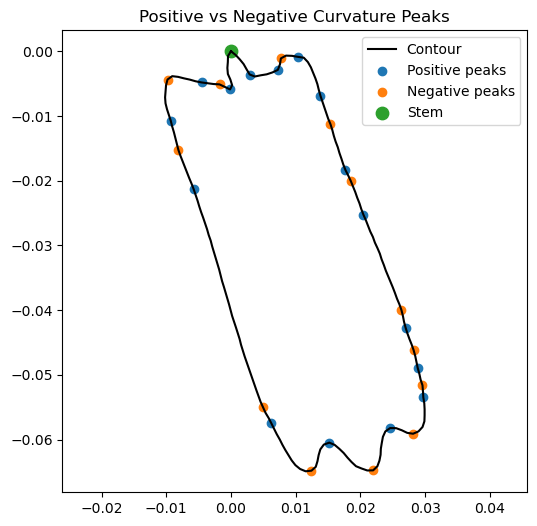

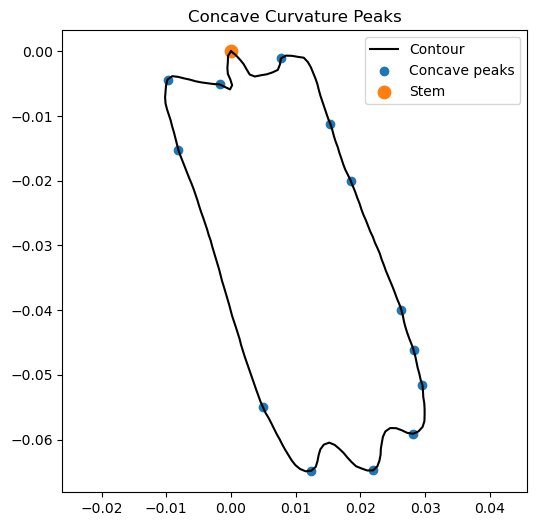

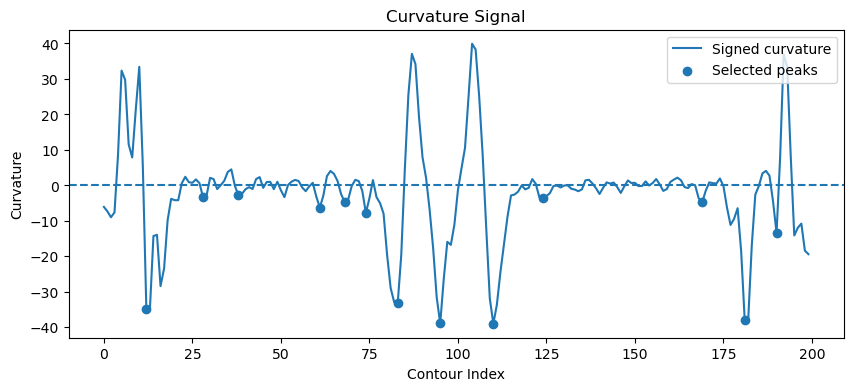

In [12]:
sample = df.iloc[0]
contour = normalize_contour_by_annotated_stem(sample)

plot_positive_vs_negative_peaks(contour, prominence=5, distance=5)

peaks, curvature, properties = find_concave_peaks(
    contour,
    prominence=5,
    distance=5,
    concave_sign="negative"
)

plot_concave_peaks(contour, peaks)
plot_curvature_signal(curvature, peaks)

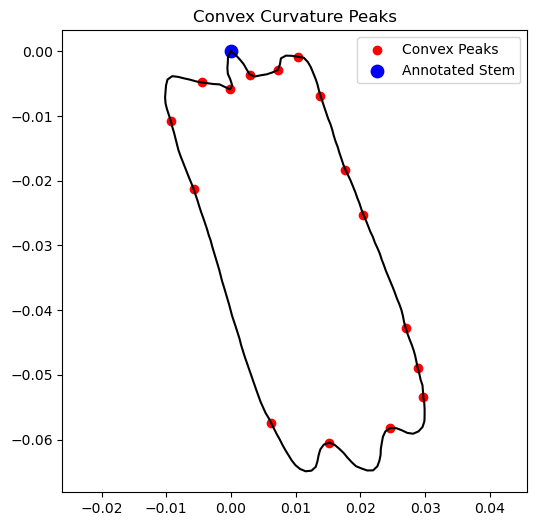

In [13]:
sample = df.iloc[0]

contour = normalize_contour_by_annotated_stem(sample)

peaks, curvature, properties = find_convex_curvature_peaks(
    contour,
    prominence=5,
    distance=5
)

plt.figure(figsize=(6, 6))

plt.plot(contour[:, 0], contour[:, 1], "-k")

plt.scatter(
    contour[peaks, 0],
    contour[peaks, 1],
    color="red",
    label="Convex Peaks"
)

plt.scatter(
    contour[0, 0],
    contour[0, 1],
    color="blue",
    s=80,
    label="Annotated Stem"
)

plt.axis("equal")
plt.legend()
plt.title("Convex Curvature Peaks")
plt.show()